# EE 446 TinyML — Knowledge Distillation with Pruning and Quantization  

## Student TODO Version: Compression of a DNN Using the UCI Human Activity Recognition Dataset

In this version, key parts of the notebook have been left for you to complete.  
Follow the instructions in each code cell and fill in the missing sections marked with `#<--- Enter your code here --->#`.


## 1. Environment Setup

This notebook assumes you are running it with the **`Python (tinyml-arduino)`** kernel.

Expected environment:
- TensorFlow 2.14.1
- TensorFlow Model Optimization 0.8.0
- NumPy, Pandas, Matplotlib, Scikit-learn
- No in-notebook package reinstallation is required

Use **Kernel → Change Kernel → `Python (tinyml-arduino)`** if needed.


In [44]:

import os
import math
import zipfile
import random
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow_model_optimization as tfmot

from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.14.1


## 2. Download and Extract the UCI HAR Dataset

The UCI HAR dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 human activity classes**
- A predefined **training split** and **test split**

This makes it a strong fit for a **fully connected DNN** and for TinyML-oriented compression experiments.


In [ ]:

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = Path("uci_har_dataset.zip")
extract_dir = Path(".")

if not zip_path.exists():
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)

dataset_root = Path("UCI HAR Dataset")
if not dataset_root.exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

print("Dataset ready at:", dataset_root.resolve())


## 3. Load the Data


In [5]:

def load_har_data(root_dir="UCI HAR Dataset"):
    root_dir = Path(root_dir)

    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32 and subtract 1
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32 and subtract 1

    path = '/mnt/c/Users/cliff/Downloads/tinyml_env_setup_package/tinyml_env_setup_package'
    
    X_train = pd.read_csv(path + "/UCI HAR Dataset/train/X_train.txt", sep = '\s+', header = None).values
    X_test = pd.read_csv(path + "/UCI HAR Dataset/test/X_test.txt", sep = '\s+', header = None).values
    y_train = pd.read_csv(path + "/UCI HAR Dataset/train/y_train.txt", sep = '\s+', header = None).values.flatten()
    y_test = pd.read_csv(path + "/UCI HAR Dataset/test/y_test.txt", sep = '\s+', header = None).values.flatten()

    y_test -= 1
    y_train-= 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING",
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)
print("Number of features:", num_features)
print("Number of classes :", num_classes)


X_train shape: (7352, 561)
y_train shape: (7352,)
X_test shape : (2947, 561)
y_test shape : (2947,)
Number of features: 561
Number of classes : 6


## 4. Quick Inspection


In [6]:

label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary


,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Define the Teacher and Student Models

The **teacher model** is intentionally larger and more expressive.  
The **student model** is smaller and is the model we ultimately want to deploy.


In [8]:

def build_teacher_model(input_dim, num_classes):
    # TODO:
    # Build a larger teacher DNN suitable for 561 numerical input features.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation = "relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation = "relu"),
        layers.BatchNormalization(), 
        layers.Dropout(0.2),
        layers.Dense(64, activation = "relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def build_student_model(input_dim, num_classes):
    # TODO:
    # Build a smaller student DNN.
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation = "relu"),
        layers.Dense(16, activation = "relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model



teacher_model = build_teacher_model(num_features, num_classes)
student_baseline_model = build_student_model(num_features, num_classes)

teacher_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 256)               143872    
                                                                 
 batch_normalization_1 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_2 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_2 (Dropout)         (None, 128)               0

## 6. Train the Teacher Model


In [16]:

teacher_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

teacher_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the teacher model on the UCI HAR training split.
teacher_history = teacher_model.fit(
    X_train, y_train, epochs = 30, callbacks = teacher_callbacks, shuffle = True, validation_split = 0.2, batch_size = 32
)


Epoch 1/30
184/184 [==============================] - 2s 6ms/step - loss: 0.0211 - accuracy: 0.9923 - val_loss: 0.1340 - val_accuracy: 0.9680
Epoch 2/30
184/184 [==============================] - 1s 5ms/step - loss: 0.0501 - accuracy: 0.9825 - val_loss: 0.1940 - val_accuracy: 0.9225
Epoch 3/30
184/184 [==============================] - 1s 5ms/step - loss: 0.0389 - accuracy: 0.9857 - val_loss: 0.2796 - val_accuracy: 0.9109
Epoch 4/30
184/184 [==============================] - 1s 5ms/step - loss: 0.0331 - accuracy: 0.9867 - val_loss: 0.0823 - val_accuracy: 0.9619


### Teacher Training Curves


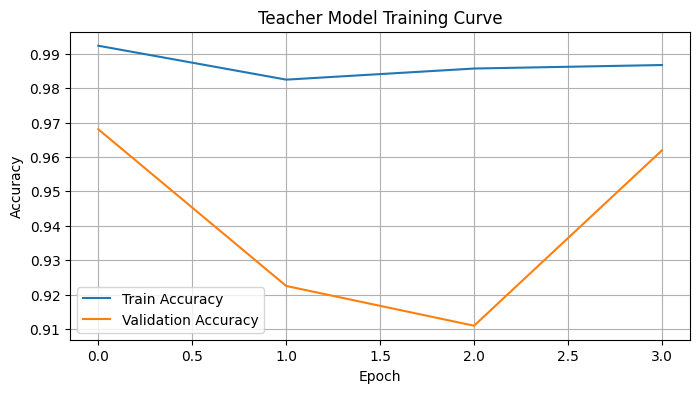

In [17]:

teacher_history_df = pd.DataFrame(teacher_history.history)

plt.figure(figsize=(8, 4))
plt.plot(teacher_history_df["accuracy"], label="Train Accuracy")
plt.plot(teacher_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Teacher Model Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 7. Evaluate the Teacher Model


In [18]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline student using the hard labels only.
student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=student_callbacks,
    shuffle=True
)


Epoch 1/30
184/184 [==============================] - 1s 3ms/step - loss: 0.8082 - accuracy: 0.7018 - val_loss: 0.3572 - val_accuracy: 0.8865
Epoch 2/30
184/184 [==============================] - 0s 2ms/step - loss: 0.2696 - accuracy: 0.9072 - val_loss: 0.2598 - val_accuracy: 0.9041
Epoch 3/30
184/184 [==============================] - 0s 2ms/step - loss: 0.1717 - accuracy: 0.9405 - val_loss: 0.2563 - val_accuracy: 0.9089
Epoch 4/30
184/184 [==============================] - 0s 2ms/step - loss: 0.1269 - accuracy: 0.9551 - val_loss: 0.1578 - val_accuracy: 0.9341
Epoch 5/30
184/184 [==============================] - 0s 2ms/step - loss: 0.1080 - accuracy: 0.9623 - val_loss: 0.1623 - val_accuracy: 0.9327
Epoch 6/30
184/184 [==============================] - 0s 2ms/step - loss: 0.0896 - accuracy: 0.9702 - val_loss: 0.1659 - val_accuracy: 0.9313
Epoch 7/30
184/184 [==============================] - 0s 2ms/step - loss: 0.0704 - accuracy: 0.9760 - val_loss: 0.1593 - val_accuracy: 0.9381
Epoch 

## 8. Train a Baseline Student Model (Hard Labels Only)

Before applying knowledge distillation, we train the smaller student model in the standard way.  
This gives us a fair baseline for comparison.


In [19]:

student_baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

student_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

student_baseline_history = student_baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=student_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 5ms/step - loss: 0.0678 - accuracy: 0.9755 - val_loss: 0.2225 - val_accuracy: 0.9273
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0676 - accuracy: 0.9772 - val_loss: 0.1706 - val_accuracy: 0.9361
Epoch 3/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0533 - accuracy: 0.9832 - val_loss: 0.1708 - val_accuracy: 0.9388
Epoch 4/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0516 - accuracy: 0.9830 - val_loss: 0.1619 - val_accuracy: 0.9368
Epoch 5/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0472 - accuracy: 0.9845 - val_loss: 0.1670 - val_accuracy: 0.9402
Epoch 6/20
92/92 [==============================] - 0s 3ms/step - loss: 0.0449 - accuracy: 0.9852 - val_loss: 0.1960 - val_accuracy: 0.9375
Epoch 7/20
92/92 [==============================] - 0s 4ms/step - loss: 0.0475 - accuracy: 0.9837 - val_loss: 0.1503 - val_accuracy: 0.9436
Epoch 8/20
92/92 [==

## 9. Evaluate the Baseline Student Model


In [28]:

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(
        self,
        optimizer,
        metrics,
        student_loss_fn,
        distillation_loss_fn,
        alpha=0.3,
        temperature=4.0,
    ):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        
        # TODO:
        # 1. Obtain teacher predictions with training=False
        teacher_predictions = self.teacher(x, training = False)
        
        # 2. Compute student predictions inside GradientTape
        with tf.GradientTape() as tape:
            student_predictions = self.student(x, training = True)
        # 3. Compute student_loss using the hard labels
            student_loss = self.student_loss_fn(y, student_predictions)
            # 4. Compute distillation_loss using softened teacher/student outputs
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_predictions / self.temperature, axis = 1),
                tf.nn.softmax(student_predictions / self.temperature, axis = 1),
            )
    
            loss = (1 - self.alpha) * student_loss + (self.alpha * (self.temperature**2)) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(y, student_predictions)

        results = {m.name: m.result() for m in self.metrics}
        results.update({
            "student_loss": student_loss,
            "distillation_loss": distillation_loss,
        })
        return results

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)

        student_loss = self.student_loss_fn(y, y_prediction)
        self.compiled_metrics.update_state(y, y_prediction)

        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results


# Part I: Knowledge Distillation

## 10. Distillation Utilities

The distilled student is trained to optimize:
- a **hard-label loss** using the true class labels
- a **soft-label loss** using the teacher's softened probability distribution


In [29]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the distilled student.
distillation_history = distiller.fit(
    X_train,
    y_train,
    epochs = 30,
    batch_size = 32,
    validation_split = 0.2,
    callbacks = distillation_callbacks, 
    shuffle = True
)


Epoch 1/30
184/184 [==============================] - 1s 3ms/step - accuracy: 0.6985 - student_loss: 0.7832 - distillation_loss: 0.0022 - val_accuracy: 0.9048 - val_student_loss: 0.0598
Epoch 2/30
184/184 [==============================] - 1s 3ms/step - accuracy: 0.9106 - student_loss: 0.2595 - distillation_loss: 7.2792e-04 - val_accuracy: 0.8987 - val_student_loss: 0.0108
Epoch 3/30
184/184 [==============================] - 1s 3ms/step - accuracy: 0.9434 - student_loss: 0.1676 - distillation_loss: 4.9170e-04 - val_accuracy: 0.9171 - val_student_loss: 0.0118
Epoch 4/30
184/184 [==============================] - 1s 3ms/step - accuracy: 0.9558 - student_loss: 0.1268 - distillation_loss: 3.8984e-04 - val_accuracy: 0.9293 - val_student_loss: 0.0113
Epoch 5/30
184/184 [==============================] - 1s 3ms/step - accuracy: 0.9604 - student_loss: 0.1086 - distillation_loss: 3.5485e-04 - val_accuracy: 0.9239 - val_student_loss: 0.0024
Epoch 6/30
184/184 [==============================] - 

## 11. Train the Distilled Student


In [30]:

distilled_student = build_student_model(num_features, num_classes)

distiller = Distiller(student=distilled_student, teacher=teacher_model)
distiller.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.3,
    temperature=4.0,
)

distillation_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

distillation_history = distiller.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=distillation_callbacks,
    verbose=1
)


Epoch 1/20
92/92 [==============================] - 1s 4ms/step - accuracy: 0.6819 - student_loss: 0.9722 - distillation_loss: 0.0028 - val_accuracy: 0.8518 - val_student_loss: 0.5303
Epoch 2/20
92/92 [==============================] - 0s 3ms/step - accuracy: 0.8924 - student_loss: 0.3787 - distillation_loss: 0.0010 - val_accuracy: 0.8967 - val_student_loss: 0.0930
Epoch 3/20
92/92 [==============================] - 0s 3ms/step - accuracy: 0.9240 - student_loss: 0.2380 - distillation_loss: 6.8509e-04 - val_accuracy: 0.9225 - val_student_loss: 0.0373
Epoch 4/20
92/92 [==============================] - 0s 3ms/step - accuracy: 0.9483 - student_loss: 0.1687 - distillation_loss: 4.8583e-04 - val_accuracy: 0.9232 - val_student_loss: 0.0198
Epoch 5/20
92/92 [==============================] - 0s 3ms/step - accuracy: 0.9594 - student_loss: 0.1343 - distillation_loss: 4.0665e-04 - val_accuracy: 0.9266 - val_student_loss: 0.0105
Epoch 6/20
92/92 [==============================] - 0s 3ms/step - ac

### Distillation Training Curves


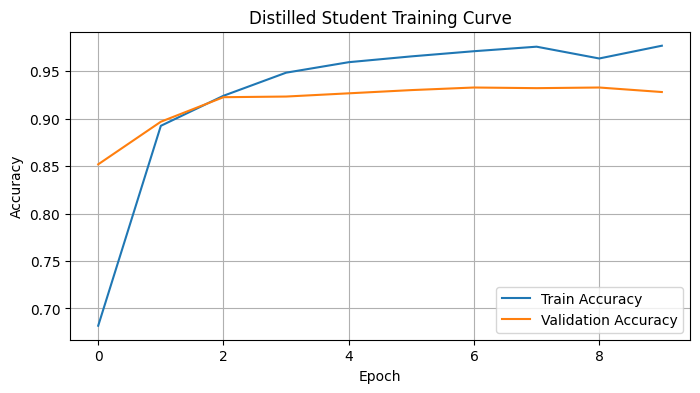

In [31]:

distillation_history_df = pd.DataFrame(distillation_history.history)

plt.figure(figsize=(8, 4))
plt.plot(distillation_history_df["accuracy"], label="Train Accuracy")
plt.plot(distillation_history_df["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Distilled Student Training Curve")
plt.legend()
plt.grid(True)
plt.show()


## 12. Evaluate the Distilled Student


Distilled Student Test Accuracy: 0.9379

                    precision    recall  f1-score   support

           WALKING     0.9532    0.9859    0.9693       496
  WALKING_UPSTAIRS     0.9308    0.9427    0.9367       471
WALKING_DOWNSTAIRS     0.9674    0.9190    0.9426       420
           SITTING     0.9385    0.8697    0.9027       491
          STANDING     0.8557    0.9474    0.8992       532
            LAYING     1.0000    0.9572    0.9781       537

          accuracy                         0.9379      2947
         macro avg     0.9409    0.9370    0.9381      2947
      weighted avg     0.9401    0.9379    0.9381      2947



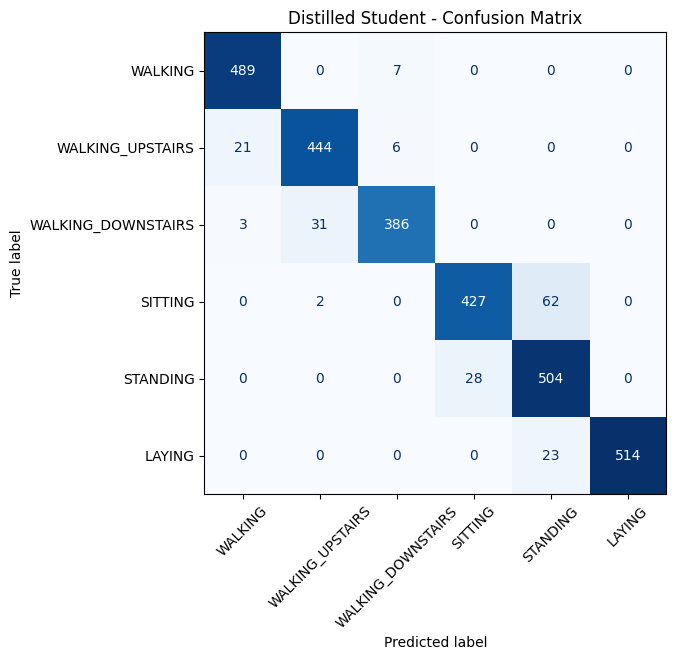

In [32]:

distilled_probs = distilled_student.predict(X_test, verbose=0)
distilled_preds = np.argmax(distilled_probs, axis=1)
distilled_acc = accuracy_score(y_test, distilled_preds)

print(f"Distilled Student Test Accuracy: {distilled_acc:.4f}\n")
print(classification_report(y_test, distilled_preds, target_names=class_names, digits=4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, distilled_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Distilled Student - Confusion Matrix")
plt.show()


## 13. Part I Comparison: Teacher vs Student vs Distilled Student


In [36]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input when the model expects int8/uint8 input.
        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(input_data / input_scale + input_zero_point).astype(np.int8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output when needed.
        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    # TODO:
    # Yield small batches from X_train for calibration.
    for sample in X_train[:300]:
        yield [sample[np.newaxis, ...].astype(np.float32)]


# Part II: Pruning and Quantization of the Distilled Student

## 14. TensorFlow Lite Utilities


In [50]:

def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] == np.int8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale
        elif output_details["dtype"] == np.uint8:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]


## 15. Convert the Distilled Student to TensorFlow Lite


In [42]:

pruning_epochs = 10
batch_size = 64
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# 1. Clone the distilled student model.
student_pruning = keras.models.clone_model(distilled_student)
# 2. Copy the distilled student weights into the cloned model.
student_pruning.set_weights(distilled_student.get_weights())
# 3. Wrap the cloned model using prune_low_magnitude with pruning_params.

pruned_distilled_model = prune_low_magnitude(student_pruning, **pruning_params)

pruned_distilled_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]


# TODO:
# Fine-tune the pruned distilled model using:
# - X_train and y_train
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
# - verbose=1
pruning_history = pruned_distilled_model.fit(
    X_train, y_train, validation_split = 0.2, epochs = pruning_epochs, batch_size = batch_size, verbose = 1, callbacks = pruning_callbacks
    #<--- Enter your code here --->#
)

Epoch 1/10
92/92 [==============================] - 2s 5ms/step - loss: 0.0741 - accuracy: 0.9782 - val_loss: 0.1479 - val_accuracy: 0.9320
Epoch 2/10
92/92 [==============================] - 0s 3ms/step - loss: 0.0894 - accuracy: 0.9752 - val_loss: 0.1557 - val_accuracy: 0.9334
Epoch 3/10
92/92 [==============================] - 0s 3ms/step - loss: 0.1921 - accuracy: 0.9531 - val_loss: 0.2135 - val_accuracy: 0.9218
Epoch 4/10
92/92 [==============================] - 1s 6ms/step - loss: 0.5790 - accuracy: 0.7960 - val_loss: 0.3690 - val_accuracy: 0.9232
Epoch 5/10
92/92 [==============================] - 0s 3ms/step - loss: 0.8552 - accuracy: 0.7118 - val_loss: 0.8171 - val_accuracy: 0.6247


## 16. Apply Magnitude-Based Pruning to the Distilled Student


In [51]:

# TODO:
# Convert the pruned model with the pruning wrappers still attached.
converter_with_mask = tf.lite.TFLiteConverter.from_keras_model(pruned_distilled_model)
pruned_with_mask_tflite = converter_with_mask.convert()
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_distilled_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# TODO:
# Strip the pruning wrappers and convert again using sparse optimization.
stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_distilled_model)#<--- Enter your code here --->#

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "distilled_stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

print(f"Pruned distilled model with mask accuracy: {pruned_with_mask_acc:.4f}")
print(f"Pruned distilled model with mask size (KB): {pruned_with_mask_size_kb:.2f}")
print(f"Stripped sparse distilled model accuracy: {stripped_sparse_acc:.4f}")
print(f"Stripped sparse distilled model size (KB): {stripped_sparse_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmpz445thx7/assets


INFO:tensorflow:Assets written to: /tmp/tmpz445thx7/assets
2026-04-20 14:33:52.991004: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 14:33:52.991074: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 14:33:52.991281: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpz445thx7
2026-04-20 14:33:52.996135: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 14:33:52.996174: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpz445thx7
2026-04-20 14:33:53.009380: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 14:33:53.070759: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpz445thx7
2026-04-20 14:33:53.095738: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp35fxpmst/assets


INFO:tensorflow:Assets written to: /tmp/tmp35fxpmst/assets
2026-04-20 14:33:53.759940: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 14:33:53.759995: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


Pruned distilled model with mask accuracy: 0.9338
Pruned distilled model with mask size (KB): 151.12
Stripped sparse distilled model accuracy: 0.9338
Stripped sparse distilled model size (KB): 69.45


2026-04-20 14:33:53.760190: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp35fxpmst
2026-04-20 14:33:53.761260: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 14:33:53.761276: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp35fxpmst
2026-04-20 14:33:53.763720: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 14:33:53.782110: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp35fxpmst
2026-04-20 14:33:53.790978: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 30789 microseconds.


## 17. Convert the Pruned Distilled Student Before and After Stripping


In [52]:

# TODO:
# Configure the converter for full integer quantization of the stripped sparse model.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8#<--- Enter your code here --->#
converter.inference_output_type = tf.int8#<--- Enter your code here --->#

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmp7q7oh78s/assets


INFO:tensorflow:Assets written to: /tmp/tmp7q7oh78s/assets
/home/cliffpm/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 14:33:58.100170: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 14:33:58.100242: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 14:33:58.100441: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7q7oh78s
2026-04-20 14:33:58.101397: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 14:33:58.101417: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp7q7oh78s
2026-04-20 14:33:58.103299: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

Stripped Sparse + INT8 Accuracy: 0.9321
Stripped Sparse + INT8 Size (KB): 20.84


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


## 18. Apply Full Integer Quantization to the Stripped Sparse Distilled Student


In [53]:

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

stripped_sparse_int8_tflite = converter.convert()
stripped_sparse_int8_size_kb = save_binary_model(
    stripped_sparse_int8_tflite,
    "distilled_stripped_sparse_int8.tflite"
)
stripped_sparse_int8_acc, stripped_sparse_int8_preds = evaluate_tflite_model(
    stripped_sparse_int8_tflite,
    X_test,
    y_test
)

print(f"Stripped Sparse + INT8 Accuracy: {stripped_sparse_int8_acc:.4f}")
print(f"Stripped Sparse + INT8 Size (KB): {stripped_sparse_int8_size_kb:.2f}")


INFO:tensorflow:Assets written to: /tmp/tmppnutzsj9/assets


INFO:tensorflow:Assets written to: /tmp/tmppnutzsj9/assets
/home/cliffpm/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-20 14:34:03.065679: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 14:34:03.065734: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 14:34:03.065956: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmppnutzsj9
2026-04-20 14:34:03.066604: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 14:34:03.066618: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmppnutzsj9
2026-04-20 14:34:03.068184: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

Stripped Sparse + INT8 Accuracy: 0.9321
Stripped Sparse + INT8 Size (KB): 36.77


## 19. Part II Comparison: Distillation, Pruning, and Quantization


In [66]:


def get_tflite_size(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    

    return len(tflite_model) / 1024.0

distilled_tflite = convert_to_tflite_fp32(distilled_student)
distilled_fp32_size_kb = len(distilled_tflite) / 1024.0

part2_results = pd.DataFrame([
    # We use get_tflite_size for the Keras models to get their "deployment" size
    ["Teacher", "Keras (Full)", teacher_model.evaluate(X_test, y_test, verbose=0)[1], get_tflite_size(teacher_model)],
    ["Student Baseline", "Keras (Small)", student_baseline_model.evaluate(X_test, y_test, verbose=0)[1], get_tflite_size(student_baseline_model)],
    ["Distilled Student", "FP32 TFLite", evaluate_tflite_model(distilled_tflite, X_test, y_test)[0], distilled_fp32_size_kb],
    ["Pruned Distilled (With Mask)", "FP32 TFLite", pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse Distilled", "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
    ["Stripped Sparse Distilled", "INT8 + Sparse", stripped_sparse_int8_acc, stripped_sparse_int8_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

part2_results["Test Accuracy"] = part2_results["Test Accuracy"].astype(float)
part2_results["Model Size (KB)"] = part2_results["Model Size (KB)"].astype(float)

part2_results

INFO:tensorflow:Assets written to: /tmp/tmpvkmdcscw/assets


INFO:tensorflow:Assets written to: /tmp/tmpvkmdcscw/assets
2026-04-20 14:49:46.489373: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 14:49:46.489454: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 14:49:46.490393: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvkmdcscw
2026-04-20 14:49:46.491707: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 14:49:46.491734: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpvkmdcscw
2026-04-20 14:49:46.495452: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 14:49:46.519510: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpvkmdcscw
2026-04-20 14:49:46.525287: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpfo1vageb/assets


INFO:tensorflow:Assets written to: /tmp/tmpfo1vageb/assets
2026-04-20 14:49:47.944774: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 14:49:47.944838: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 14:49:47.945012: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfo1vageb
2026-04-20 14:49:47.947466: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 14:49:47.947483: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfo1vageb
2026-04-20 14:49:47.954272: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 14:49:48.015797: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpfo1vageb
2026-04-20 14:49:48.033634: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp_sg5dl30/assets


INFO:tensorflow:Assets written to: /tmp/tmp_sg5dl30/assets
2026-04-20 14:49:48.818150: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-20 14:49:48.818208: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-20 14:49:48.818413: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_sg5dl30
2026-04-20 14:49:48.819367: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 14:49:48.819382: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_sg5dl30
2026-04-20 14:49:48.822176: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-20 14:49:48.860270: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp_sg5dl30
2026-04-20 14:49:48.873052: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

,Model,Format,Test Accuracy,Model Size (KB)
0,Teacher,Keras (Full),0.915507,727.281250
1,Student Baseline,Keras (Small),0.921276,74.789062
2,Distilled Student,FP32 TFLite,0.937903,74.824219
3,Pruned Distilled (With Mask),FP32 TFLite,0.933831,151.125000
4,Stripped Sparse Distilled,FP32 + Sparse,0.933831,69.449219
5,Stripped Sparse Distilled,INT8 + Sparse,0.932134,36.773438


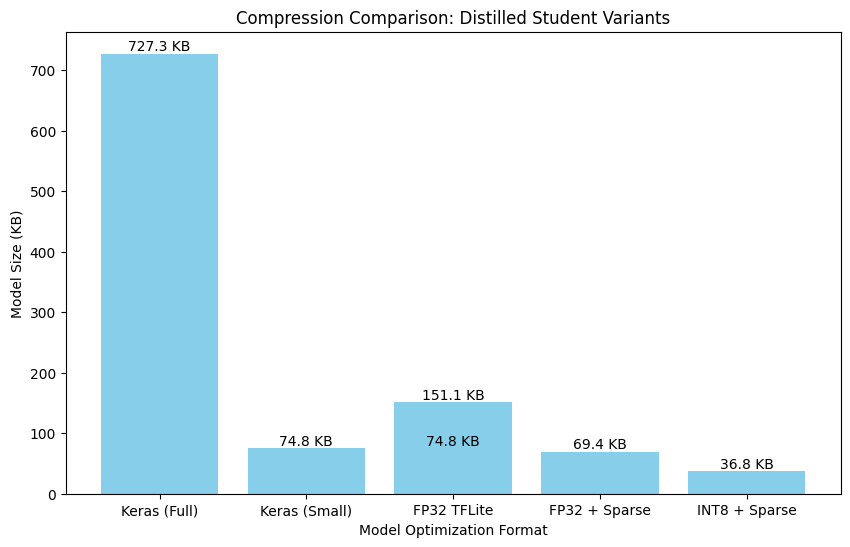

In [67]:

plot_df = part2_results[part2_results["Model Size (KB)"] != "N/A"].copy()

plot_df["Format"] = plot_df["Format"].astype(str)
plot_df["Model Size (KB)"] = plot_df["Model Size (KB)"].astype(float)

plt.figure(figsize=(10, 6))
bars = plt.bar(plot_df["Format"], plot_df["Model Size (KB)"], color='skyblue')

plt.xlabel("Model Optimization Format")
plt.ylabel("Model Size (KB)")
plt.title("Compression Comparison: Distilled Student Variants")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.1f} KB', ha='center', va='bottom')

plt.show()

### Confusion Matrix for the Final Sparse INT8 Distilled Student


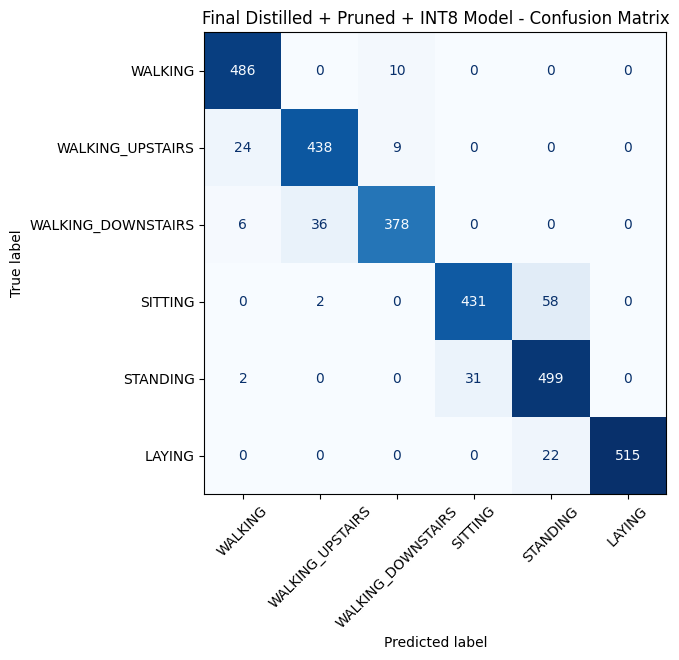

In [60]:

disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_int8_preds),
    display_labels=class_names
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Final Distilled + Pruned + INT8 Model - Confusion Matrix")
plt.show()


## 20. Summary Questions

Answer the following in your lab report:
1. How did the **baseline student** compare with the **distilled student**? The distilled student outperformed the baseline student slightly and both have around the same size.  The baseline learned from the hard labels while the distilled learned from the soft probabilities provided from the teacher model.
2. Did **knowledge distillation** help the smaller model retain performance? Yes knowledge distillation was effective, and our distilled student actually achieved a higher accuracy than the teacher, so the distillation process acted as a form of regularization to help the student model generalize better.
3. What happened to the model size after **pruning** and after **INT8 quantization**? The model after pruning went up to 151 KB almost double the size, this is because of the additional pruning mask that is used to zero out weights, however afterwards the weights are disacrded and then following int8 quantization reduces the overall size further.
4. Which model would you choose for **Arduino deployment**, and why? I would choose the stripped sparse int8 model for Arduino deployment, due to the high retained accuracy along with the smallest model size which is most appropirate given the resource constraints on the Arduino.
5. Why is the final **sparse INT8 model** a good TinyML deployment candidate?
The final sparse INT8 model would be a good TinyML deployment candidate because again it maintains around the same accuracy results, has the lowest network size which is good for micro controller deployment and it uses integer arithmetic, which is much faster and doesn't require a floating point unit.

## 21. Submission Requirements

Submit the following:
1. Your completed notebook
2. Screenshots of the most important results:
   - teacher accuracy
   - baseline student accuracy
   - distilled student accuracy
   - final sparse INT8 model accuracy and size
3. The exported TensorFlow Lite model:
   - `distilled_stripped_sparse_int8.tflite`
4. Short answers to the summary questions
